# Lab 7.04 - Time series analysis

In [3]:
# Package Imports
import numpy as np                                  # Scientific computing
import pandas as pd                                 # Dataframe manipulation
import scipy.stats as stats                         # Statistical tests
import matplotlib.pyplot as plt                     # Basic visualization
import seaborn as sns                               # Advanced data visualization
from sklearn.linear_model import LinearRegression   # Linear regression model
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.api import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose

### Exercise 4 - Airline ticket data

Consider the airline ticket data in the file airline ticket data.csv  

- Create a time series chart of the data. Based on what you see, which of the exponential smoothing models do you think should be used for forecasting? Why?
- Create and train the model. Predict the values for the next 12 months.
- Create a plot with the airline ticket data and the predicted values for the next 12 months.

In [29]:
data = pd.read_csv('https://raw.githubusercontent.com/HoGentTIN/dsai-labs/main/data/airline%20ticket%20data.csv', date_format='%m/%Y', delimiter = ";", parse_dates=['Month']).set_index(['Month'])
data.head()

,Tickets
Month,
2018-01-01,605
2018-02-01,647
2018-03-01,636
2018-04-01,612
2018-05-01,714


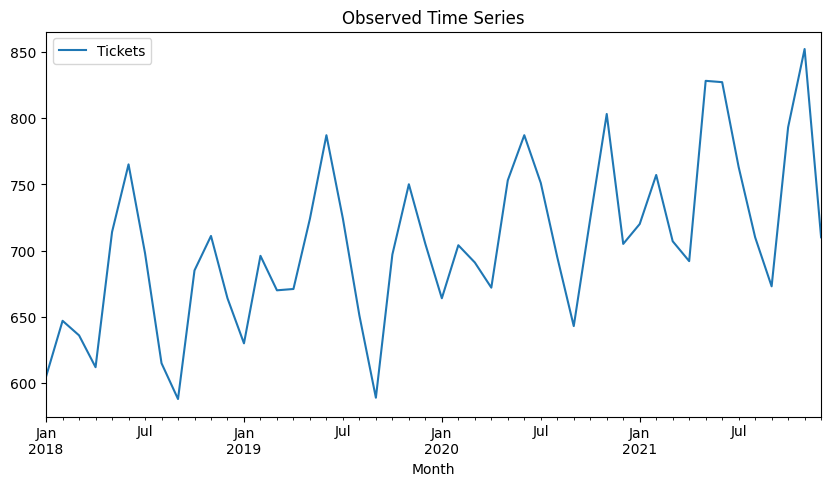

In [20]:
data.plot(y='Tickets', figsize=[10,5], title="Observed Time Series");
plt.show()

In [22]:
train = data[:'2020-12-01']
test = data['2021-01-01':]

In [23]:
data_tes = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12, freq='MS').fit()
data_tes_forecast = data_tes.forecast(12)

In [31]:
data_tes.forecast(12)

2021-01-01    687.333374
2021-02-01    736.666678
2021-03-01    720.000051
2021-04-01    705.999975
2021-05-01    784.666791
2021-06-01    834.000132
2021-07-01    778.666702
2021-08-01    708.000131
2021-09-01    661.000112
2021-10-01    756.333336
2021-11-01    809.000203
2021-12-01    745.666650
Freq: MS, dtype: float64

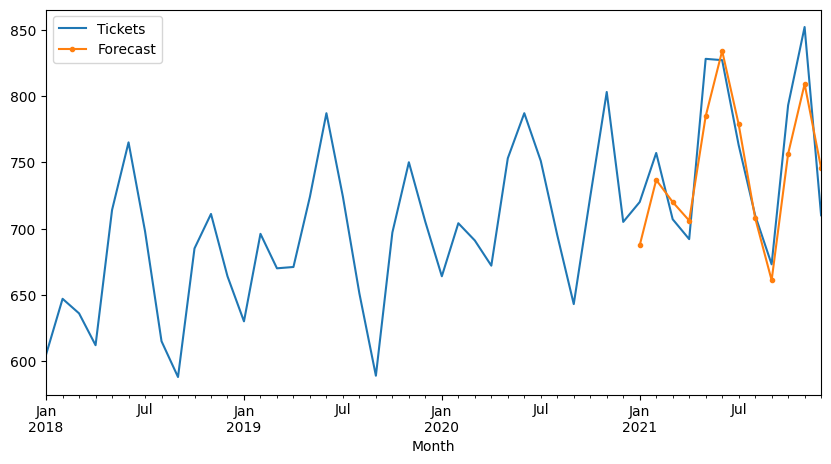

In [32]:
data.plot(y='Tickets', figsize=[10,5])
data_tes_forecast.plot(marker='.', legend=True, label='Forecast');

In [36]:
y_true = test.values
y_predicted = data_tes_forecast.values
mae_tes = mean_absolute_error(y_true, y_predicted)

print(f"MAE TES = {mae_tes}")

MAE TES = 22.944406940644672


## Source
Business Analytics Data Analysis & Decision Making 